In [1]:
import pandas as pd 

In [2]:
import numpy as np

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df= pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv', header=1)

In [6]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,246,245,245,245,245,245,245,245,245,245,245,245,245,244
unique,33,5,2,20,63,19,40,174,167,199,107,175,128,9
top,01,07,2012,35,55,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,8,62,244,29,10,43,133,8,5,5,8,5,12,131


In [7]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.0 KB


In [9]:
#  data cleaning

In [31]:
# missing value
df[df.isnull().any(axis=1)]


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
163,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


The dataset can be divided into two sets based on region from 122th index, we can make a new column based on the region
1: "Bejaia Region Dataset"
2: " Sidi Bel Abbes Region DataSet"

Add new column with region 

In [11]:
df.loc[:122, "Region"]=0
df.loc[122:, "Region"]=1


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    str    
 1   month        245 non-null    str    
 2   year         245 non-null    str    
 3   Temperature  245 non-null    str    
 4    RH          245 non-null    str    
 5    Ws          245 non-null    str    
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
 14  Region       246 non-null    float64
dtypes: float64(1), str(14)
memory usage: 29.0 KB


In [32]:
df[['Region']]= df[['Region']].astype(int)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [37]:
#  Remove The Null Values

df=df.dropna().reset_index(drop=True)

In [38]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [40]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [41]:
df=df.drop(122).reset_index(drop=True)

In [42]:
print(df.iloc[[122]])
df=df.drop(122).reset_index(drop=True)
df.iloc[[122]]

     day  month  year  Temperature  RH  Ws Rain  FFMC DMC    DC  ISI  BUI  \
122    5      6  2012           32  60  14  0.2  77.1   6  17.6  1.8  6.5   

     FWI      Classes  Region  
122  0.9  not fire          1  


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,6,6,2012,35,54,11,0.1,83.7,8.4,26.3,3.1,9.3,3.1,fire,1


In [44]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [45]:
#  Fix spaces in column names
df.columns= df.columns.str.strip()

In [47]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [48]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [49]:
#  Change The required columns as integer data type
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']]= df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          238 non-null    int64
 1   month        238 non-null    int64
 2   year         238 non-null    int64
 3   Temperature  238 non-null    int64
 4   RH           238 non-null    int64
 5   Ws           238 non-null    int64
 6   Rain         238 non-null    str  
 7   FFMC         238 non-null    str  
 8   DMC          238 non-null    str  
 9   DC           238 non-null    str  
 10  ISI          238 non-null    str  
 11  BUI          238 non-null    str  
 12  FWI          238 non-null    str  
 13  Classes      238 non-null    str  
 14  Region       238 non-null    int64
dtypes: int64(7), str(8)
memory usage: 28.0 KB


In [50]:
# #  Convert to float
# # objects=[features for features in df.columns if df[features].dtype == 'object']
# objects

# for i in objects:
#     df[i] = df[i].str.replace(' ', '')
    
    

# for i in objects:
#     if i != 'Classes':
#         df[i] = pd.to_numeric(df[i], errors='coerce')
    
    
    
# df.info()

In [54]:
#  Chaning the other columns to float

strin=[features for features in df.columns if df[features].dtype=='str']

In [55]:
for i in strin:
    if i!= 'Classes':
        df[i]=df[i].astype(float)
        
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          238 non-null    int64  
 1   month        238 non-null    int64  
 2   year         238 non-null    int64  
 3   Temperature  238 non-null    int64  
 4   RH           238 non-null    int64  
 5   Ws           238 non-null    int64  
 6   Rain         238 non-null    float64
 7   FFMC         238 non-null    float64
 8   DMC          238 non-null    float64
 9   DC           238 non-null    float64
 10  ISI          238 non-null    float64
 11  BUI          238 non-null    float64
 12  FWI          238 non-null    float64
 13  Classes      238 non-null    str    
 14  Region       238 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 28.0 KB


In [56]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,238.000000,238.000000,238.0,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,16.029412,7.533613,2012.0,32.184874,61.882353,15.537815,0.750000,78.141597,14.910924,50.231513,4.818908,16.955462,7.173109,0.487395
std,8.734430,1.104710,0.0,3.654871,14.907975,2.821825,2.010683,14.236795,12.417259,47.835849,4.162209,14.256124,7.456622,0.500894
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,9.000000,7.000000,2012.0,30.000000,52.000000,14.000000,0.000000,72.625000,6.000000,14.700000,1.425000,6.200000,0.800000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.750000,11.450000,34.300000,3.750000,12.550000,4.900000,0.000000
75%,23.750000,8.750000,2012.0,35.000000,73.750000,17.000000,0.475000,88.300000,20.900000,71.225000,7.300000,22.900000,11.825000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [58]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [59]:
#  save the clean dataset
df.to_csv('CLEANED_Algerian_dataset.csv', index=False)

## Exploratory Data Analysis

df.head()

df.head()

In [60]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [74]:
df_copy=df
df_copy['Classes'].value_counts()

Classes
fire             131
not fire          96
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [68]:
df_copy=df.drop(['day', 'month', 'year'],axis=1)


In [69]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [75]:
#  encoding the categories to classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'), 0,1)

In [76]:
df_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [78]:
# Categories in classes
df_copy['Classes'].value_counts()

Classes
1    137
0    101
Name: count, dtype: int64

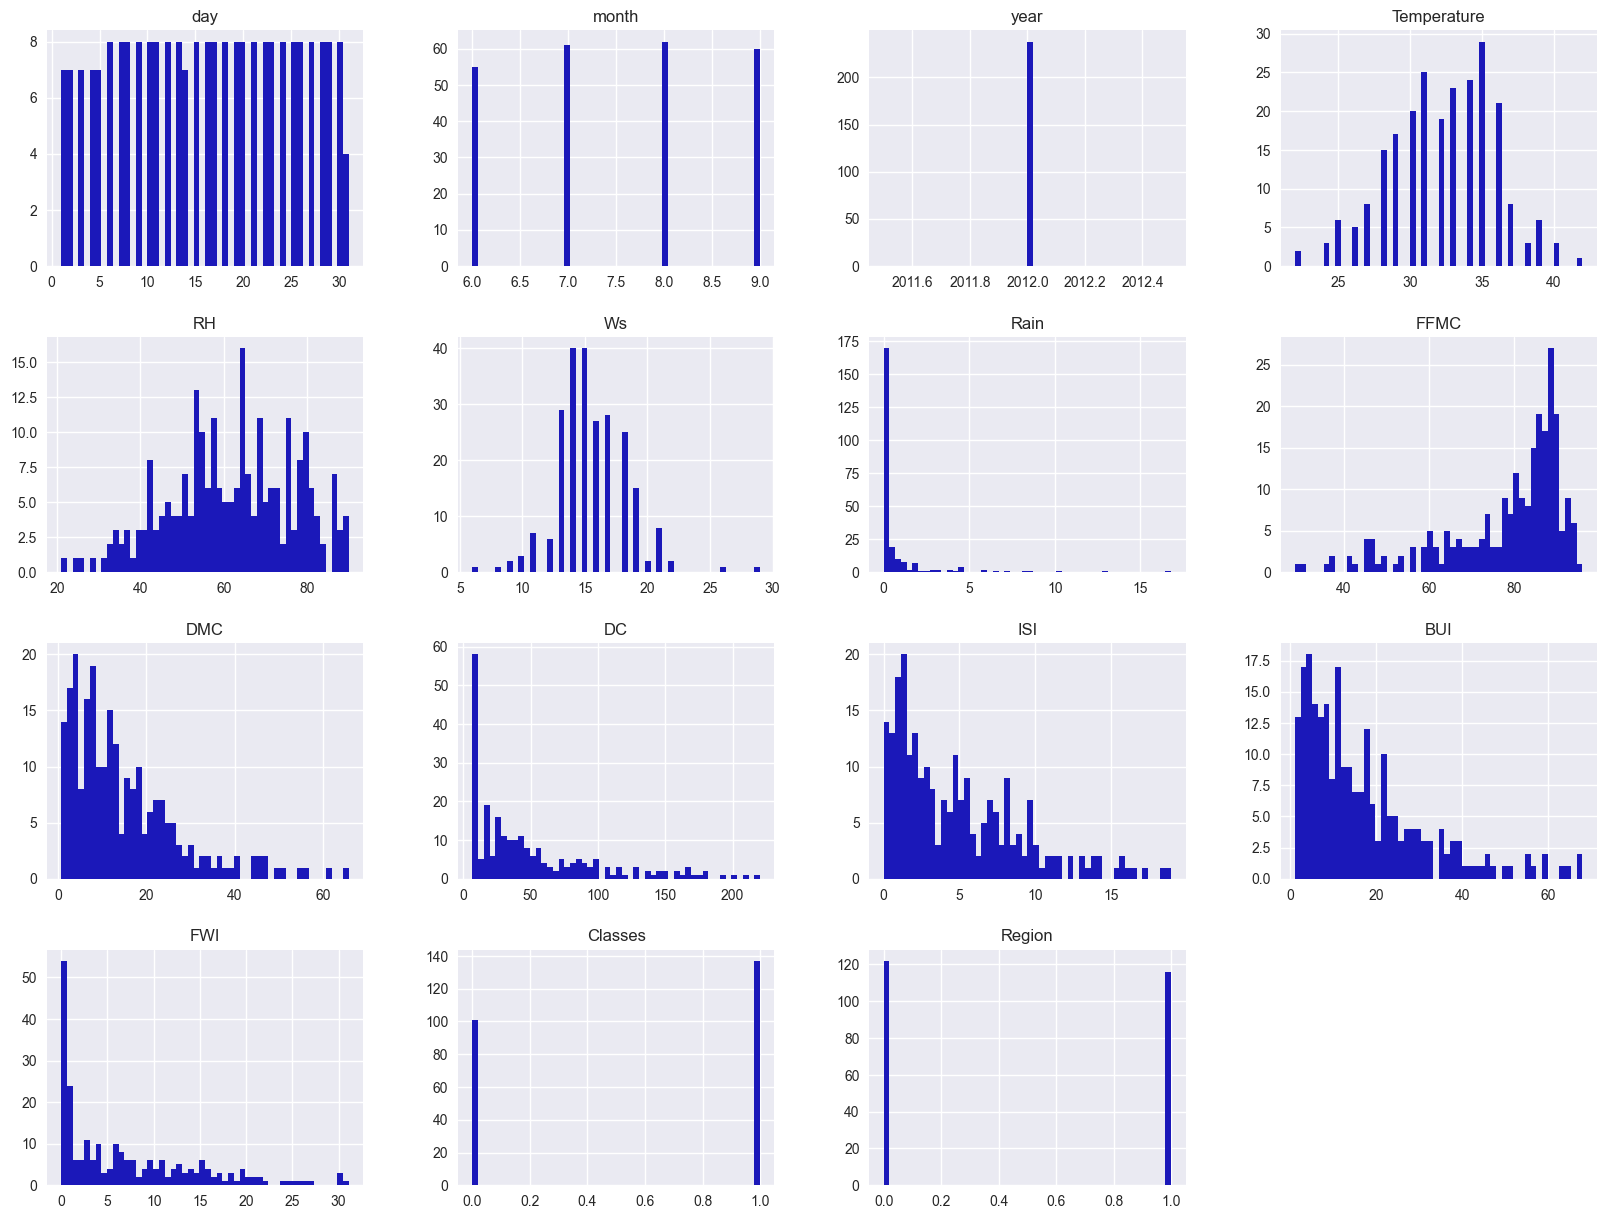

In [83]:
#  plot desnity plot for all features
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50, figsize=(20,15), color='#1B18B9')
plt.show()

In [85]:
# percentage for pie chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100

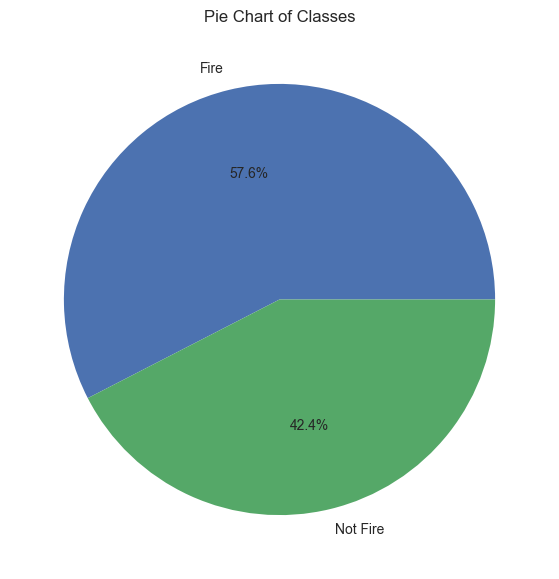

In [87]:
# plotting pie chart
classlabels=["Fire", "Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage, labels=classlabels, autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()


## Correlation

In [88]:
df_copy.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
day,1.000000,-0.043176,NaN,0.086403,-0.061217,0.025035,-0.105028,0.200743,0.478957,0.518482,0.158271,0.505344,0.334025,0.174558,0.032394
month,-0.043176,1.000000,NaN,-0.070518,-0.027429,-0.062673,0.044735,-0.011612,0.044021,0.106561,0.041844,0.061583,0.059221,-0.008522,0.031270
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,0.086403,-0.070518,NaN,1.000000,-0.650011,-0.293201,-0.324403,0.679710,0.482919,0.372513,0.602572,0.456740,0.564996,0.514362,0.282464
RH,-0.061217,-0.027429,NaN,-0.650011,1.000000,0.255672,0.216930,-0.641088,-0.403289,-0.220149,-0.684901,-0.347961,-0.578701,-0.427945,-0.420031
Ws,0.025035,-0.062673,NaN,-0.293201,0.255672,1.000000,0.179670,-0.188960,-0.015257,0.067180,-0.005863,0.017390,0.018638,-0.089606,-0.168326
Rain,-0.105028,0.044735,NaN,-0.324403,0.216930,0.179670,1.000000,-0.541766,-0.286090,-0.295849,-0.345112,-0.297408,-0.322952,-0.379416,-0.047341
FFMC,0.200743,-0.011612,NaN,0.679710,-0.641088,-0.188960,-0.541766,1.000000,0.598780,0.501616,0.738019,0.587043,0.689894,0.770063,0.250388
DMC,0.478957,0.044021,NaN,0.482919,-0.403289,-0.015257,-0.286090,0.598780,1.000000,0.874097,0.675033,0.981946,0.873827,0.577192,0.214868
DC,0.518482,0.106561,NaN,0.372513,-0.220149,0.067180,-0.295849,0.501616,0.874097,1.000000,0.501194,0.941179,0.735633,0.502247,-0.062929


<Axes: >

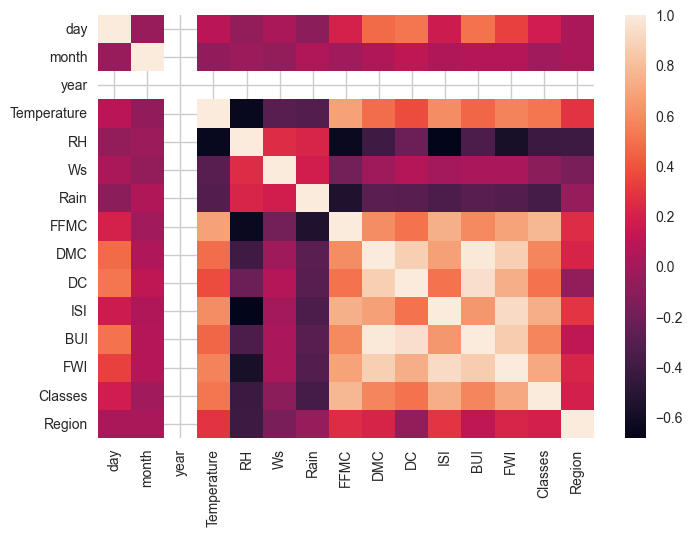

In [100]:
# marking down a heatmap
sns.heatmap(df_copy.corr()) # lighter color means more correlation

<Axes: ylabel='FWI'>

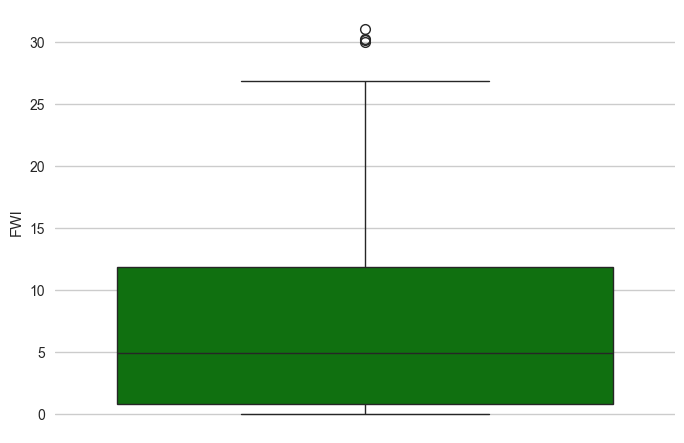

In [101]:
## Box Plots 
sns.boxplot(df_copy['FWI'], color="green")

In [102]:
df_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


Text(0.5, 1.0, 'Fire Analysis of Bejaia Region')

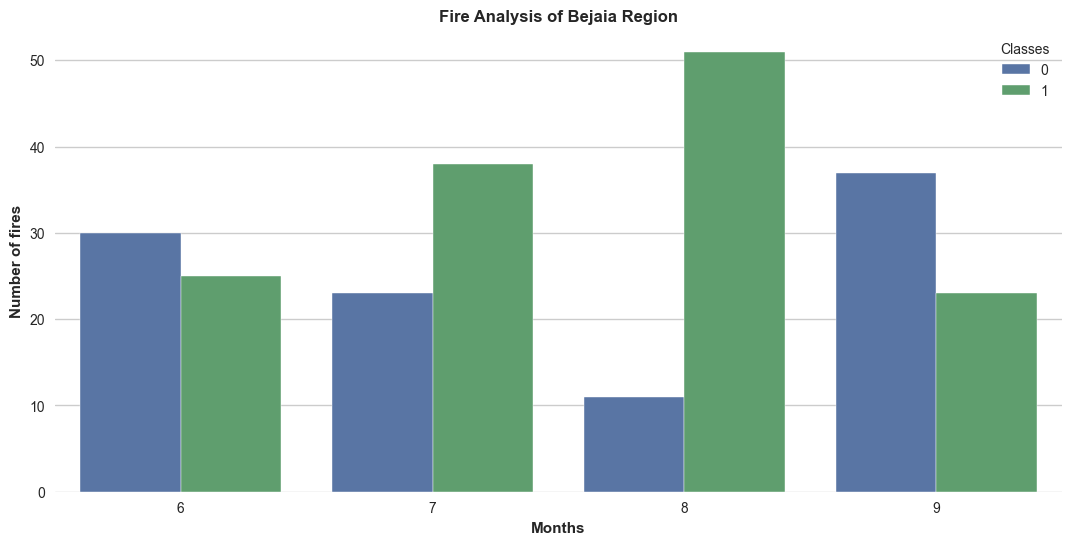

In [104]:
## Monthly Fire Analysis
dftemp= df_copy.loc[df_copy['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=df)
plt.ylabel('Number of fires', weight= 'bold')
plt.xlabel('Months', weight='bold')
plt.title("Fire Analysis of Bejaia Region", weight= 'bold')


Text(0.5, 1.0, 'Fire Analysis of Sidi-Bel Region')

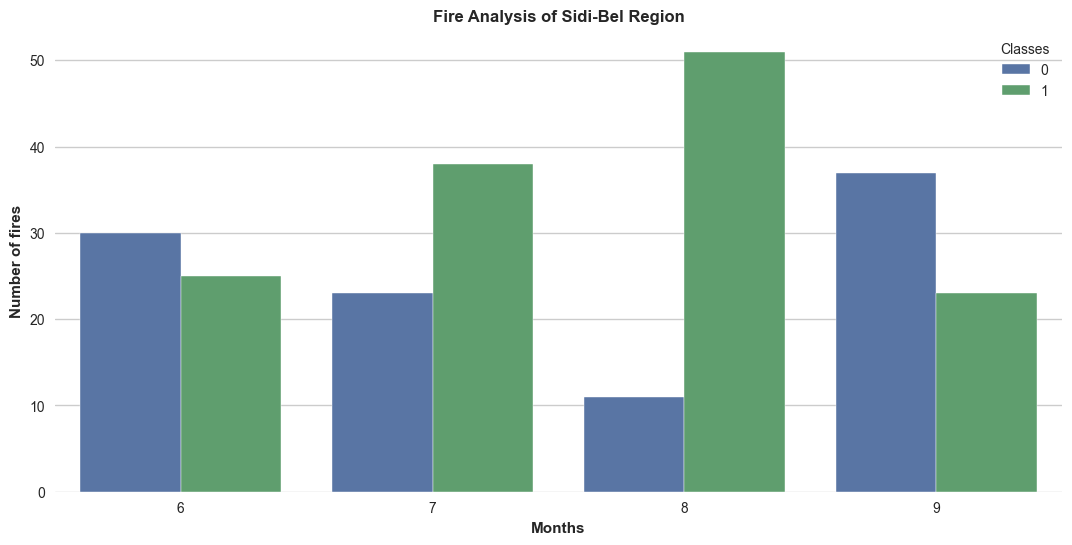

In [105]:
## Monthly Fire Analysis
dftemp= df_copy.loc[df_copy['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=df)
plt.ylabel('Number of fires', weight= 'bold')
plt.xlabel('Months', weight='bold')
plt.title("Fire Analysis of Sidi-Bel Region", weight= 'bold')


Its id observed that the most number of forest fires for both regions. And from the above plot of months we can undersatnd sa few things


Most of the fires Happened in August and very high Fires happened in only 3 Months --> June, July, August

Less fire in September